# Notebook 2: Feature Engineering
Goal: Build the complete feature matrix `features_long.parquet` from all 7 datasets.

In [6]:
import os
import sys
import warnings
import pickle

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

# ─── Configuration Constants ──────────────────────────────────────────────────
ROOT_DIR = os.path.abspath('.')
RAW_DATA_DIR = os.path.join(ROOT_DIR, "data", "raw")
PROCESSED_DIR = os.path.join(ROOT_DIR, "data", "processed")
ARTIFACTS_DIR = os.path.join(PROCESSED_DIR, "model_artifacts")

RAW_FILES = {
    "transport_cost":  os.path.join(RAW_DATA_DIR, "transport_cost_by_product.csv"),
    "bilateral_lsci":  os.path.join(RAW_DATA_DIR, "bilateral_shipping_connectivity_index.csv"),
    "country_lsci":    os.path.join(RAW_DATA_DIR, "country_shipping_connectivity_index.csv"),
    "port_throughput": os.path.join(RAW_DATA_DIR, "container_port_throughput.csv"),
    "merchant_fleet":  os.path.join(RAW_DATA_DIR, "merchant_fleet.csv"),
    "seaborne_trade":  os.path.join(RAW_DATA_DIR, "seaborne_trade.csv"),
    "vessel_pct":      os.path.join(RAW_DATA_DIR, "vessel_percent_of_global_fleet.csv"),
    "disruption":      os.path.join(RAW_DATA_DIR, "global_supply_chain_disruption_v1.csv"),
    "weather":         os.path.join(RAW_DATA_DIR, "country_date_conditions.csv"),
}

FEATURES_PATH = os.path.join(PROCESSED_DIR, "features_long.parquet")
CONSTANTS_PATH = os.path.join(ARTIFACTS_DIR, "normalization_constants.pkl")

YEARS = list(range(2016, 2022))  # 2016–2021 inclusive
PRODUCT_CODES = [8517, 2106, 3304, 9404, 6109]

# Country name normalization mapping
NAME_CANONICAL = {
    "Korea, Republic of": "Republic of Korea",
    "Korea, Dem. People's Rep. of": "Dem. People's Rep. of Korea",
    "Congo, Dem. Rep. of the": "Dem. Rep. of the Congo",
    "Moldova, Republic of": "Republic of Moldova",
    "Tanzania, United Republic of": "United Republic of Tanzania",
    "United States of America": "United States",
    "Iran (Islamic Republic of)": "Iran (Islamic Republic of)",
    "Viet Nam": "Viet Nam",
    "Turkiye": "Turkiye",
}

# City to country mapping for disruption data
CITY_COUNTRY_MAP = {
    "Mumbai, IN": "India",
    "Shenzhen, CN": "China",
    "Shanghai, CN": "China",
    "Hamburg, DE": "Germany",
    "Tokyo, JP": "Japan",
    "Santos, BR": "Brazil",
    "Rotterdam, NL": "Netherlands (Kingdom of the)",
    "New York, US": "United States",
    "Los Angeles, US": "United States",
    "Singapore, SG": "Singapore",
    "Felixstowe, UK": "United Kingdom",
}

# Weather severity mapping (0-1, higher = worse)
WEATHER_SEVERITY_MAP = {
    "Sunny": 0.00, "Clear": 0.00,
    "Partly cloudy": 0.05, "Partly Cloudy": 0.05,
    "Cloudy": 0.10, "Overcast": 0.10,
    "Mist": 0.15, "Fog": 0.15, "Freezing fog": 0.15,
    "Patchy rain possible": 0.20, "Patchy rain nearby": 0.20,
    "Patchy snow possible": 0.20, "Patchy snow nearby": 0.20,
    "Thundery outbreaks possible": 0.20,
    "Light drizzle": 0.25, "Patchy light drizzle": 0.25, "Patchy light rain": 0.25,
    "Light rain": 0.30, "Light rain shower": 0.30,
    "Light freezing rain": 0.30, "Freezing drizzle": 0.30,
    "Moderate rain": 0.35, "Moderate rain at times": 0.35,
    "Light snow": 0.40, "Light snow showers": 0.40,
    "Patchy light snow": 0.40, "Patchy moderate snow": 0.40,
    "Light sleet": 0.40, "Light sleet showers": 0.40,
    "Heavy rain": 0.50, "Heavy rain at times": 0.50,
    "Moderate or heavy rain shower": 0.50, "Heavy freezing drizzle": 0.50,
    "Moderate or heavy freezing rain": 0.50, "Moderate or heavy sleet": 0.50,
    "Moderate snow": 0.60, "Moderate or heavy snow showers": 0.60,
    "Patchy heavy snow": 0.60,
    "Thundery outbreaks in nearby": 0.65,
    "Patchy light rain in area with thunder": 0.65,
    "Patchy light rain with thunder": 0.65,
    "Patchy light snow in area with thunder": 0.65,
    "Moderate or heavy rain in area with thunder": 0.70,
    "Moderate or heavy rain with thunder": 0.70,
    "Moderate or heavy snow in area with thunder": 0.70,
    "Heavy snow": 0.80, "Torrential rain shower": 0.80,
    "Blowing snow": 0.90, "Blizzard": 1.00,
}
WEATHER_SEVERITY_DEFAULT = 0.30

# ML feature list
ML_FEATURES = [
    "origin_lsci", "dest_lsci", "bilateral_lsci",
    "origin_teu", "dest_teu", "teu_log_product",
    "origin_fleet_pct", "dest_fleet_pct", "fleet_supply",
    "origin_loaded_kt", "dest_loaded_kt",
    "origin_discharged_kt", "dest_discharged_kt",
    "trade_imbalance", "lsci_asymmetry",
    "origin_vessel_pct", "dest_vessel_pct",
    "historical_mean_rate",
    "year_int", "product_cat", "post_covid",
    "bilateral_lsci_is_imputed", "origin_teu_is_imputed",
    "dest_teu_is_imputed", "historical_mean_rate_is_imputed",
]

print('Environment ready.')

Environment ready.


## Data Loading Functions

The following functions load and normalize each raw CSV dataset into a consistent long format.

In [7]:
def _normalize_country(series: pd.Series) -> pd.Series:
    """Apply NAME_CANONICAL mapping to a country-name column."""
    return series.map(lambda x: NAME_CANONICAL.get(x, x) if isinstance(x, str) else x)


def _melt_years(df: pd.DataFrame, id_vars: list, value_col_pattern: str,
                new_col: str) -> pd.DataFrame:
    """
    Melt year-wide columns that contain `value_col_pattern` into long format.
    Extracts the integer year from the column name prefix (e.g. '2016_...' → 2016).
    """
    year_cols = [c for c in df.columns if value_col_pattern in c and c[:4].isdigit()]
    melted = df.melt(id_vars=id_vars, value_vars=year_cols,
                     var_name="_raw_col", value_name=new_col)
    melted["year"] = melted["_raw_col"].str[:4].astype(int)
    return melted.drop(columns=["_raw_col"])


def load_transport_cost() -> pd.DataFrame:
    """
    Returns long-format transport cost DataFrame.
    Columns: origin, destination, product_code, product_label, year, freight_rate
    """
    df = pd.read_csv(RAW_FILES["transport_cost"])
    df["Origin_Label"] = _normalize_country(df["Origin_Label"])
    df["Destination_Label"] = _normalize_country(df["Destination_Label"])

    df = _melt_years(
        df,
        id_vars=["Origin_Label", "Destination_Label", "Product_Code", "Product_Label"],
        value_col_pattern="Advalorem_freight_rate_Value",
        new_col="freight_rate",
    )
    df = df.rename(columns={
        "Origin_Label": "origin",
        "Destination_Label": "destination",
        "Product_Code": "product_code",
        "Product_Label": "product_label",
    })
    df = df[df["year"].isin(YEARS)].reset_index(drop=True)
    return df


def load_bilateral_lsci() -> pd.DataFrame:
    """
    Returns long-format bilateral connectivity index.
    Columns: origin, destination, year, bilateral_lsci
    """
    df = pd.read_csv(RAW_FILES["bilateral_lsci"])
    df = df[df["Quarter_Label"].str.startswith("Q1")].copy()
    df["year"] = df["Quarter_Label"].str.extract(r"(\d{4})").astype(int)
    df = df[df["year"].isin(YEARS)]

    partner_cols = [c for c in df.columns if "_Index_Value" in c]
    df = df.melt(
        id_vars=["Economy_Label", "year"],
        value_vars=partner_cols,
        var_name="_partner_raw",
        value_name="bilateral_lsci",
    )
    df["destination"] = df["_partner_raw"].str.replace("_Index_Value", "", regex=False)
    df = df.rename(columns={"Economy_Label": "origin"})

    df["origin"] = _normalize_country(df["origin"])
    df["destination"] = _normalize_country(df["destination"])

    return df[["origin", "destination", "year", "bilateral_lsci"]].reset_index(drop=True)


def load_country_lsci() -> pd.DataFrame:
    """
    Returns long-format country-level LSCI connectivity index.
    Columns: country, year, country_lsci
    """
    df = pd.read_csv(RAW_FILES["country_lsci"])
    df = df.rename(columns={"Economy_Label": "country"})
    df["country"] = _normalize_country(df["country"])

    year_cols = [c for c in df.columns if c.startswith("Q1 ") and "_Value" in c]
    df = df.melt(
        id_vars=["country"],
        value_vars=year_cols,
        var_name="_raw_col",
        value_name="country_lsci",
    )
    df["year"] = df["_raw_col"].str.extract(r"Q1 (\d{4})").astype(int)
    return df[df["year"].isin(YEARS)][["country", "year", "country_lsci"]].reset_index(drop=True)


def load_port_throughput() -> pd.DataFrame:
    """
    Returns long-format container port throughput in TEU.
    Columns: country, year, teu
    """
    df = pd.read_csv(RAW_FILES["port_throughput"])
    df = df[df["Economy_Label"] != "Individual economies"].copy()
    df = df.rename(columns={"Economy_Label": "country"})
    df["country"] = _normalize_country(df["country"])

    df = _melt_years(
        df,
        id_vars=["country"],
        value_col_pattern="TEU_Twenty_foot_Equivalent_Unit_Value",
        new_col="teu",
    )
    return df[df["year"].isin(YEARS)].reset_index(drop=True)


def load_merchant_fleet() -> pd.DataFrame:
    """
    Returns long-format merchant fleet share (% of world total).
    Columns: country, year, fleet_pct
    """
    df = pd.read_csv(RAW_FILES["merchant_fleet"])
    df = df[df["Economy_Label"] != "Individual economies"].copy()
    df = df.rename(columns={"Economy_Label": "country"})
    df["country"] = _normalize_country(df["country"])

    df = _melt_years(
        df,
        id_vars=["country"],
        value_col_pattern="Percentage_of_total_world_Value",
        new_col="fleet_pct",
    )
    return df[df["year"].isin(YEARS)].reset_index(drop=True)


def load_seaborne_trade() -> pd.DataFrame:
    """
    Returns wide-format seaborne trade with separate loaded/discharged columns.
    Columns: country, year, loaded_kt, discharged_kt
    """
    df = pd.read_csv(RAW_FILES["seaborne_trade"])
    df = df[df["Economy_Label"] != "Individual economies"].copy()
    df = df.rename(columns={"Economy_Label": "country", "CargoType_Label": "cargo_type"})
    df["country"] = _normalize_country(df["country"])

    df = _melt_years(
        df,
        id_vars=["country", "cargo_type"],
        value_col_pattern="Metric_tons_in_thousands_Value",
        new_col="volume_kt",
    )
    df = df[df["year"].isin(YEARS)]

    df_pivot = df.pivot_table(
        index=["country", "year"],
        columns="cargo_type",
        values="volume_kt",
        aggfunc="sum",
    ).reset_index()
    df_pivot.columns.name = None

    rename_map = {}
    for c in df_pivot.columns:
        if "loaded" in c.lower() and "discharged" not in c.lower():
            rename_map[c] = "loaded_kt"
        elif "discharged" in c.lower():
            rename_map[c] = "discharged_kt"
    df_pivot = df_pivot.rename(columns=rename_map)

    for col in ["loaded_kt", "discharged_kt"]:
        if col not in df_pivot.columns:
            df_pivot[col] = np.nan

    return df_pivot[["country", "year", "loaded_kt", "discharged_kt"]].reset_index(drop=True)


def load_vessel_pct() -> pd.DataFrame:
    """
    Returns long-format vessel % of global fleet.
    For 2016-2018, values are back-filled from 2019.
    Columns: country, year, vessel_pct, vessel_pct_extrapolated
    """
    df = pd.read_csv(RAW_FILES["vessel_pct"])
    df = df[df["FlagOfRegistration_Label"] != "Individual economies"].copy()
    df = df.rename(columns={"FlagOfRegistration_Label": "country"})
    df["country"] = _normalize_country(df["country"])

    df = _melt_years(
        df,
        id_vars=["country"],
        value_col_pattern="Percentage_of_global_fleet_value_Value",
        new_col="vessel_pct",
    )
    df = df[df["year"].isin([2019, 2020, 2021])].copy()
    df["vessel_pct_extrapolated"] = False

    # Back-fill to 2016-2018 using 2019 values
    df_2019 = df[df["year"] == 2019][["country", "vessel_pct"]].copy()
    extra_rows = []
    for yr in [2016, 2017, 2018]:
        tmp = df_2019.copy()
        tmp["year"] = yr
        tmp["vessel_pct_extrapolated"] = True
        extra_rows.append(tmp)
    df = pd.concat([df] + extra_rows, ignore_index=True)
    return df[df["year"].isin(YEARS)].sort_values(["country", "year"]).reset_index(drop=True)


def load_weather_severity() -> pd.DataFrame:
    """
    Per-country mean weather severity from daily observations.
    Columns: country, weather_severity (float 0-1)
    """
    df = pd.read_csv(RAW_FILES["weather"])
    df["severity"] = df["condition_text"].map(WEATHER_SEVERITY_MAP).fillna(WEATHER_SEVERITY_DEFAULT)
    result = (
        df.groupby("country")["severity"]
        .mean()
        .reset_index()
        .rename(columns={"severity": "weather_severity"})
    )
    result["country"] = _normalize_country(result["country"])
    return result


def load_disruption_metrics() -> pd.DataFrame:
    """
    Per-country disruption metrics derived from shipment-level data.
    Columns: country, otd_rate, mean_delay_norm, congestion_rate, geo_conflict_rate, mean_gri
    """
    df = pd.read_csv(RAW_FILES["disruption"])
    df["origin_country"] = df["Origin_City"].map(CITY_COUNTRY_MAP)
    df["dest_country"] = df["Destination_City"].map(CITY_COUNTRY_MAP)

    origin_df = df.rename(columns={"origin_country": "country"})
    dest_df = df.rename(columns={"dest_country": "country"})
    stacked = pd.concat([
        origin_df[["country", "Delivery_Status", "Delay_Days",
                   "Disruption_Event", "Geopolitical_Risk_Index"]],
        dest_df[["country", "Delivery_Status", "Delay_Days",
                 "Disruption_Event", "Geopolitical_Risk_Index"]],
    ], ignore_index=True)
    stacked = stacked.dropna(subset=["country"])

    def _agg(group):
        n = len(group)
        otd_rate = (group["Delivery_Status"] == "On Time").sum() / n
        mean_delay_norm = min(group["Delay_Days"].mean() / 10.0, 1.0)
        congestion_rate = ((group["Disruption_Event"] == "Port Congestion").sum() / n)
        geo_conflict_rate = (
            (group["Disruption_Event"] == "Geopolitical Conflict (Route Diversion)").sum() / n
        )
        mean_gri = group["Geopolitical_Risk_Index"].mean()
        return pd.Series({
            "otd_rate": otd_rate,
            "mean_delay_norm": mean_delay_norm,
            "congestion_rate": congestion_rate,
            "geo_conflict_rate": geo_conflict_rate,
            "mean_gri": mean_gri,
        })

    result = stacked.groupby("country").apply(_agg, include_groups=False).reset_index()
    return result


def load_all() -> dict:
    """Load and return all datasets as a dict of DataFrames."""
    return {
        "transport_cost": load_transport_cost(),
        "bilateral_lsci": load_bilateral_lsci(),
        "country_lsci": load_country_lsci(),
        "port_throughput": load_port_throughput(),
        "merchant_fleet": load_merchant_fleet(),
        "seaborne_trade": load_seaborne_trade(),
        "vessel_pct": load_vessel_pct(),
        "weather_severity": load_weather_severity(),
        "disruption_metrics": load_disruption_metrics(),
    }

print('Data loading functions defined.')

Data loading functions defined.


## 1. Feature Engineering Pipeline

This section implements the complete feature engineering pipeline inline:
1. Load all 7 raw datasets
2. Build observation table from transport_cost (base)
3. Join in all supporting features via left joins
4. Create derived features (asymmetry, imbalance, scale indicators, etc.)
5. Apply null-fill strategy with imputation flags
6. Save outputs

In [8]:
# ── Load all raw datasets ────────────────────────────────────────────────────
print("Loading raw datasets...")
data = load_all()
tc = data["transport_cost"]
bil = data["bilateral_lsci"]
clsci = data["country_lsci"]
teu = data["port_throughput"]
fleet = data["merchant_fleet"]
trade = data["seaborne_trade"]
vpct = data["vessel_pct"]

print(f"  Transport cost rows: {len(tc):,}")

# ── Filter to 5 products ──────────────────────────────────────────────────────
tc = tc[tc["product_code"].isin(PRODUCT_CODES)].copy()
print(f"  After product filter: {len(tc):,} rows")

# ── Join bilateral LSCI ───────────────────────────────────────────────────────
df = tc.merge(
    bil.rename(columns={"bilateral_lsci": "bilateral_lsci"}),
    on=["origin", "destination", "year"],
    how="left",
)
df["bilateral_lsci_is_imputed"] = df["bilateral_lsci"].isna().astype(int)
df["bilateral_lsci"] = df["bilateral_lsci"].fillna(0.0)

# ── Join country LSCI (origin & destination) ──────────────────────────────────
df = df.merge(
    clsci.rename(columns={"country": "origin", "country_lsci": "origin_lsci"}),
    on=["origin", "year"],
    how="left",
)
df = df.merge(
    clsci.rename(columns={"country": "destination", "country_lsci": "dest_lsci"}),
    on=["destination", "year"],
    how="left",
)

# ── Join TEU (port throughput for origin & destination) ───────────────────────
df = df.merge(
    teu.rename(columns={"country": "origin", "teu": "origin_teu"}),
    on=["origin", "year"],
    how="left",
)
df["origin_teu_is_imputed"] = df["origin_teu"].isna().astype(int)
df = df.merge(
    teu.rename(columns={"country": "destination", "teu": "dest_teu"}),
    on=["destination", "year"],
    how="left",
)
df["dest_teu_is_imputed"] = df["dest_teu"].isna().astype(int)

# ── Join merchant fleet ───────────────────────────────────────────────────────
df = df.merge(
    fleet.rename(columns={"country": "origin", "fleet_pct": "origin_fleet_pct"}),
    on=["origin", "year"],
    how="left",
)
df = df.merge(
    fleet.rename(columns={"country": "destination", "fleet_pct": "dest_fleet_pct"}),
    on=["destination", "year"],
    how="left",
)

# ── Join seaborne trade ───────────────────────────────────────────────────────
df = df.merge(
    trade.rename(columns={
        "country": "origin",
        "loaded_kt": "origin_loaded_kt",
        "discharged_kt": "origin_discharged_kt"
    }),
    on=["origin", "year"],
    how="left",
)
df = df.merge(
    trade.rename(columns={
        "country": "destination",
        "loaded_kt": "dest_loaded_kt",
        "discharged_kt": "dest_discharged_kt"
    }),
    on=["destination", "year"],
    how="left",
)

# ── Join vessel % ─────────────────────────────────────────────────────────────
df = df.merge(
    vpct[["country", "year", "vessel_pct"]].rename(
        columns={"country": "origin", "vessel_pct": "origin_vessel_pct"}
    ),
    on=["origin", "year"],
    how="left",
)
df = df.merge(
    vpct[["country", "year", "vessel_pct"]].rename(
        columns={"country": "destination", "vessel_pct": "dest_vessel_pct"}
    ),
    on=["destination", "year"],
    how="left",
)

# ── Historical mean rate (2016-2019 only, avoid data leakage) ─────────────────
historical_obs = df[
    df["freight_rate"].notna() & df["year"].isin([2016, 2017, 2018, 2019])
]
grp_mean = (
    historical_obs
    .groupby(["origin", "destination", "product_code"])["freight_rate"]
    .mean()
    .rename("historical_mean_rate")
)
df = df.join(grp_mean, on=["origin", "destination", "product_code"])

# Fill missing historical rates with product median
product_medians = (
    df[df["freight_rate"].notna()]
    .groupby("product_code")["freight_rate"]
    .median()
)
df["historical_mean_rate_is_imputed"] = df["historical_mean_rate"].isna().astype(int)
for prod, med in product_medians.items():
    mask = (df["product_code"] == prod) & df["historical_mean_rate"].isna()
    df.loc[mask, "historical_mean_rate"] = med

# ── Null-fill numeric features ────────────────────────────────────────────────
_fill_zero = [
    "bilateral_lsci",
    "origin_teu", "dest_teu",
    "origin_fleet_pct", "dest_fleet_pct",
    "origin_loaded_kt", "dest_loaded_kt",
    "origin_discharged_kt", "dest_discharged_kt",
    "origin_vessel_pct", "dest_vessel_pct",
]
df[_fill_zero] = df[_fill_zero].fillna(0.0)

# country_lsci: fill with year median, then 0.0
for yr in YEARS:
    mask = df["year"] == yr
    med_o = df.loc[mask & df["origin_lsci"].notna(), "origin_lsci"].median()
    med_d = df.loc[mask & df["dest_lsci"].notna(), "dest_lsci"].median()
    df.loc[mask & df["origin_lsci"].isna(), "origin_lsci"] = med_o
    df.loc[mask & df["dest_lsci"].isna(), "dest_lsci"] = med_d

df["origin_lsci"] = df["origin_lsci"].fillna(0.0)
df["dest_lsci"] = df["dest_lsci"].fillna(0.0)

# ── Derived / engineered features ─────────────────────────────────────────────
df["lsci_asymmetry"] = (df["origin_lsci"] - df["dest_lsci"]).abs()
df["trade_imbalance"] = (
    (df["origin_loaded_kt"] - df["dest_loaded_kt"])
    / (df["origin_loaded_kt"] + df["dest_loaded_kt"] + 1e-9)
)
df["teu_log_product"] = (
    np.log1p(df["origin_teu"]) * np.log1p(df["dest_teu"])
)
df["fleet_supply"] = df["origin_fleet_pct"] + df["dest_fleet_pct"]
df["post_covid"] = (df["year"] >= 2020).astype(int)
df["year_int"] = df["year"].astype(int)
df["product_cat"] = (
    df["product_code"]
    .astype("category")
    .cat.set_categories(PRODUCT_CODES)
    .cat.codes
    .astype(int)
)

# ── Calculate normalization constants ─────────────────────────────────────────
bilateral_lsci_p95 = float(
    df.loc[df["bilateral_lsci"] > 0, "bilateral_lsci"].quantile(0.95)
)
median_fleet_pct = float(
    df.loc[df["fleet_supply"] > 0, "fleet_supply"].median()
)
median_lsci = float(df.loc[df["origin_lsci"] > 0, "origin_lsci"].median())
teu_p95 = float(
    df.loc[df["origin_teu"] > 0, "origin_teu"].quantile(0.95)
)

weather_data = data.get("weather_severity")
disruption_data = data.get("disruption_metrics")
weather_severity_median = float(
    weather_data["weather_severity"].median()
) if weather_data is not None and len(weather_data) > 0 else 0.10
rel_median = float(
    disruption_data["otd_rate"].median()
) if disruption_data is not None and len(disruption_data) > 0 else 0.87
sec_median_gri = float(
    disruption_data["mean_gri"].median()
) if disruption_data is not None and len(disruption_data) > 0 else 0.50

constants = {
    "bilateral_lsci_p95": bilateral_lsci_p95,
    "median_fleet_pct": median_fleet_pct,
    "median_lsci": median_lsci,
    "teu_p95": teu_p95,
    "weather_severity_median": weather_severity_median,
    "rel_median": rel_median,
    "sec_median_gri": sec_median_gri,
}

os.makedirs(ARTIFACTS_DIR, exist_ok=True)
with open(CONSTANTS_PATH, "wb") as f:
    pickle.dump(constants, f)
print(f"  Saved normalization constants → {CONSTANTS_PATH}")

print(f"\nFeature table shape: {df.shape}")
print(f"  Observed (non-null) freight rates: {df['freight_rate'].notna().sum():,}")
print(f"  Missing freight rates (targets):   {df['freight_rate'].isna().sum():,}")

# ── Save feature table ────────────────────────────────────────────────────────
os.makedirs(PROCESSED_DIR, exist_ok=True)
df.to_parquet(FEATURES_PATH, index=False)
print(f"  Saved → {FEATURES_PATH}")

# ── Display sample ─────────────────────────────────────────────────────────────
print(f'\n Dtypes:')
print(df.dtypes.to_string())
print(f'\nSample rows:')
display(df.head(5))

Loading raw datasets...
  Transport cost rows: 375,522
  After product filter: 375,522 rows
  Saved normalization constants → g:\My Drive\NUS\IS5126\Final Project\data\processed\model_artifacts\normalization_constants.pkl

Feature table shape: (375522, 31)
  Observed (non-null) freight rates: 239,499
  Missing freight rates (targets):   136,023
  Saved → g:\My Drive\NUS\IS5126\Final Project\data\processed\features_long.parquet

 Dtypes:
origin                              object
destination                         object
product_code                         int64
product_label                       object
freight_rate                       float64
year                                 int64
bilateral_lsci                     float64
bilateral_lsci_is_imputed            int64
origin_lsci                        float64
dest_lsci                          float64
origin_teu                         float64
origin_teu_is_imputed                int64
dest_teu                           float64


,origin,destination,product_code,product_label,freight_rate,year,bilateral_lsci,bilateral_lsci_is_imputed,origin_lsci,dest_lsci,...,dest_vessel_pct,historical_mean_rate,historical_mean_rate_is_imputed,lsci_asymmetry,trade_imbalance,teu_log_product,fleet_supply,post_covid,year_int,product_cat
0,Afghanistan,Angola,9404,Mattress supports; articles of bedding (e.g. m...,NaN,2016,0.0,1,121.71,82.42,...,0.00,0.100,1,39.29,-0.975237,0.0,0.000,0,2016,3
1,Afghanistan,Argentina,6109,"T-shirts, singlets and other vests; knitted or...",NaN,2016,0.0,1,121.71,101.04,...,0.02,0.048,0,20.67,-0.979162,0.0,0.006,0,2016,4
2,Afghanistan,Argentina,8517,"Telephone sets, including telephones for cellu...",NaN,2016,0.0,1,121.71,101.04,...,0.02,0.091,0,20.67,-0.979162,0.0,0.006,0,2016,0
3,Afghanistan,Australia,2106,Food preparations not elsewhere specified or i...,NaN,2016,0.0,1,121.71,157.43,...,0.76,0.043,0,35.72,-0.998490,0.0,0.000,0,2016,1
4,Afghanistan,Australia,6109,"T-shirts, singlets and other vests; knitted or...",0.094,2016,0.0,1,121.71,157.43,...,0.76,0.094,0,35.72,-0.998490,0.0,0.000,0,2016,4


## 2. Feature Distribution Analysis

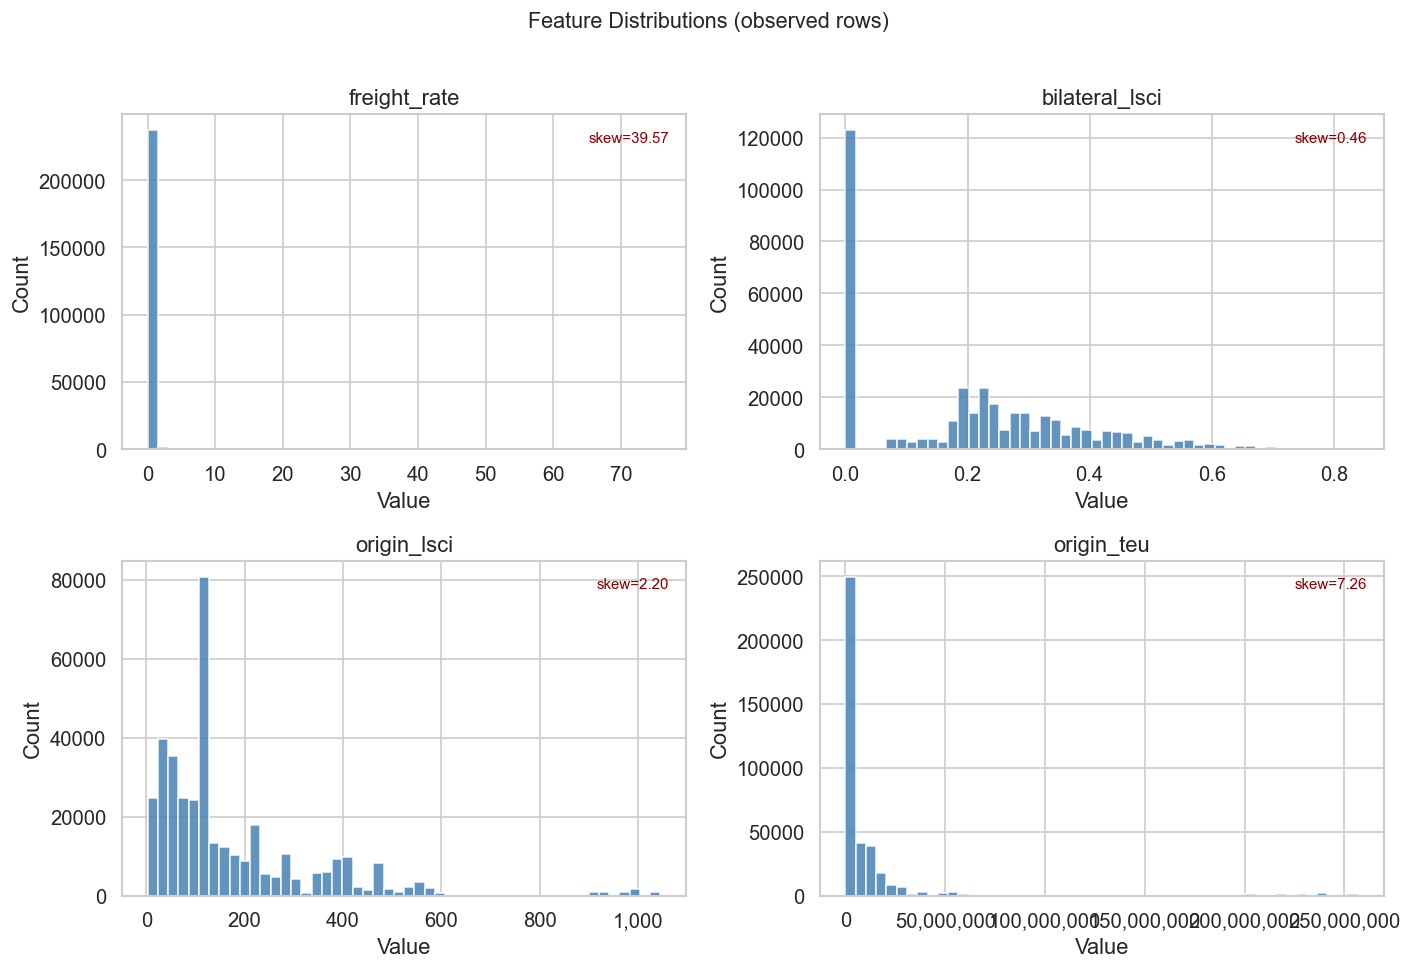

In [9]:
import matplotlib.ticker as mticker

# Key numeric features to inspect
PLOT_FEATURES = ['freight_rate', 'bilateral_lsci', 'origin_lsci', 'origin_teu']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for ax, feat in zip(axes, PLOT_FEATURES):
    data = df[feat].dropna()
    ax.hist(data, bins=50, edgecolor='white', color='steelblue', alpha=0.85)
    ax.set_title(feat)
    ax.set_xlabel('Value')
    ax.set_ylabel('Count')
    if data.max() > 1000:
        ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
    else:
        ax.xaxis.set_major_formatter(mticker.ScalarFormatter())
    skew_val = float(data.skew())
    ax.text(0.97, 0.95, f'skew={skew_val:.2f}', transform=ax.transAxes,
            ha='right', va='top', fontsize=9, color='darkred')

fig.suptitle('Feature Distributions (observed rows)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 3. Correlation Analysis

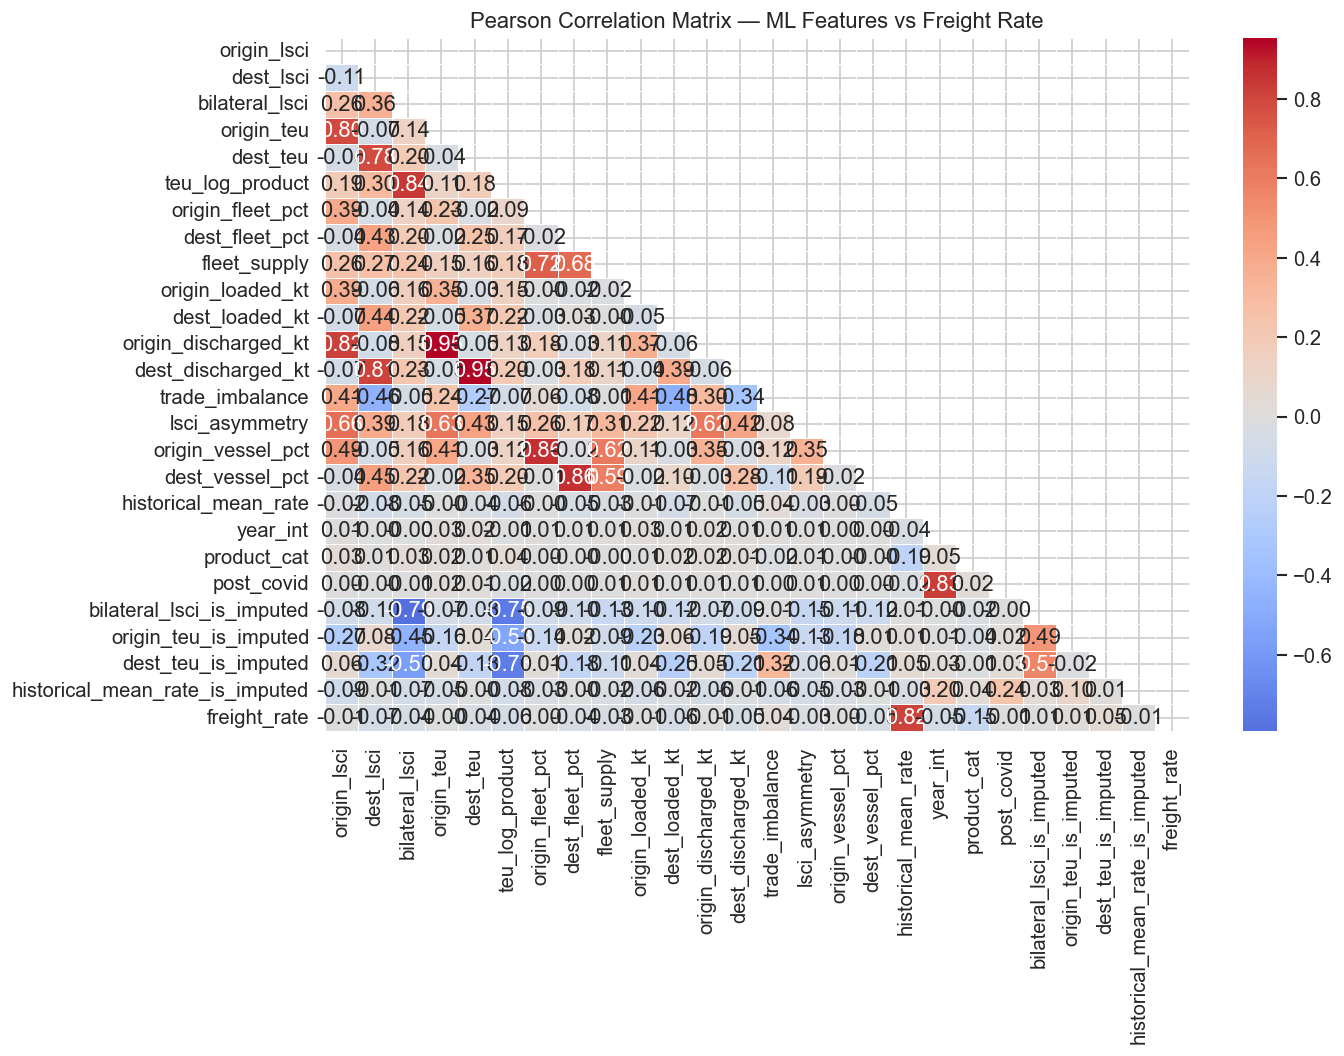

Top 5 features correlated with freight_rate:
historical_mean_rate    0.815905
product_cat             0.152514
dest_lsci               0.071802
teu_log_product         0.060953
dest_loaded_kt          0.060460


In [10]:
# Use only observed (non-null) freight_rate rows
obs = df[df['freight_rate'].notna()].copy()

# Keep only features that exist in the dataframe
avail_feats = [f for f in ML_FEATURES if f in obs.columns]
corr_cols = avail_feats + ['freight_rate']

corr_matrix = obs[corr_cols].corr()

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True, fmt='.2f',
    cmap='coolwarm', center=0,
    linewidths=0.3,
    ax=ax
)
ax.set_title('Pearson Correlation Matrix — ML Features vs Freight Rate')
plt.tight_layout()
plt.show()

# Top-5 features correlated with freight_rate
top5 = (
    corr_matrix['freight_rate']
    .drop('freight_rate')
    .abs()
    .sort_values(ascending=False)
    .head(5)
)
print('Top 5 features correlated with freight_rate:')
print(top5.to_string())

## 4. COVID-19 Signal

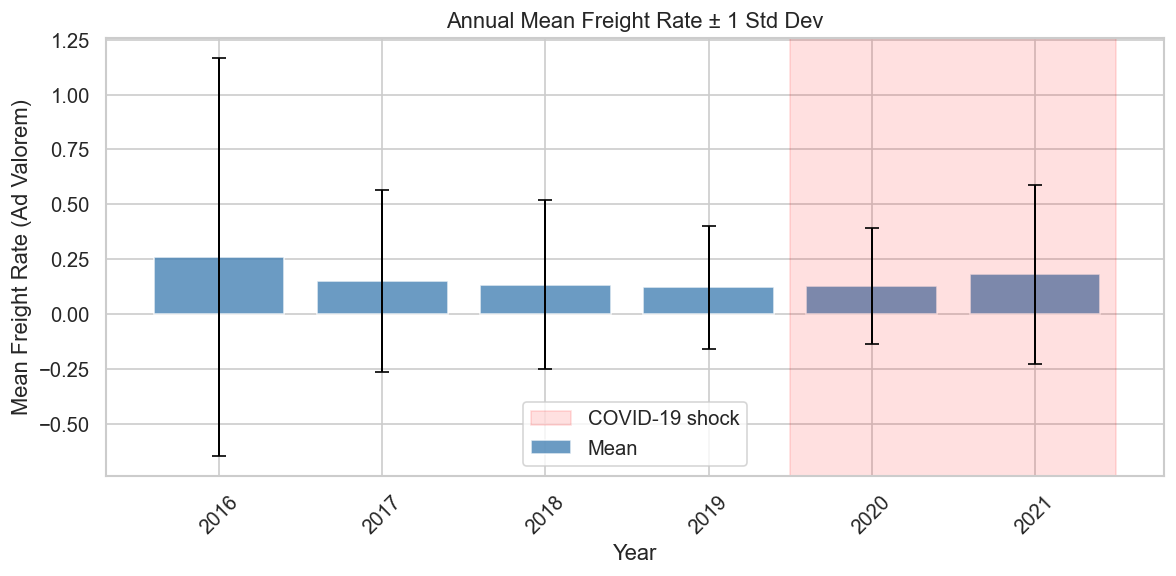

  2019: mean = 0.1215
  2020: mean = 0.1267
  2021: mean = 0.1816


In [11]:
yearly = (
    obs
    .groupby('year')['freight_rate']
    .agg(['mean', 'std'])
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(yearly['year'].astype(str), yearly['mean'], color='steelblue', alpha=0.8, label='Mean')
ax.errorbar(
    yearly['year'].astype(str), yearly['mean'],
    yerr=yearly['std'], fmt='none', color='black', capsize=4, linewidth=1.2
)

year_list = yearly['year'].astype(str).tolist()
if '2020' in year_list and '2021' in year_list:
    ax.axvspan(
        year_list.index('2020') - 0.5,
        year_list.index('2021') + 0.5,
        alpha=0.12, color='red', label='COVID-19 shock'
    )

ax.set_xlabel('Year')
ax.set_ylabel('Mean Freight Rate (Ad Valorem)')
ax.set_title('Annual Mean Freight Rate ± 1 Std Dev')
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

for yr in [2019, 2020, 2021, 2022]:
    row = yearly[yearly['year'] == yr]
    if not row.empty:
        print(f'  {yr}: mean = {row["mean"].values[0]:.4f}')

## 5. Missing Value Summary

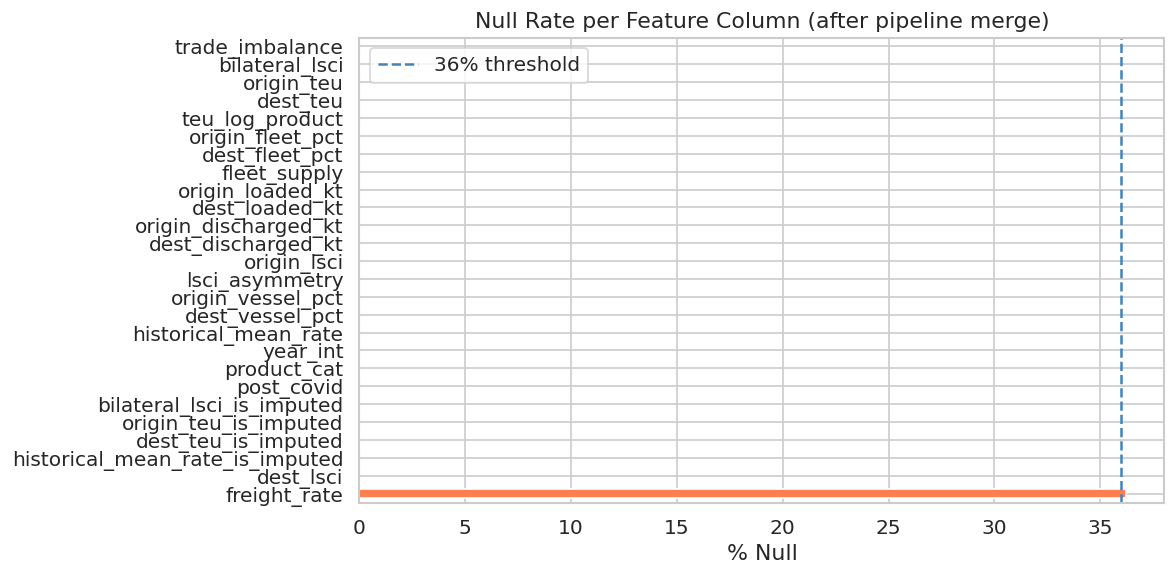

freight_rate                       36.222378
dest_lsci                           0.000000
historical_mean_rate_is_imputed     0.000000
dest_teu_is_imputed                 0.000000
origin_teu_is_imputed               0.000000
bilateral_lsci_is_imputed           0.000000
post_covid                          0.000000
product_cat                         0.000000
year_int                            0.000000
historical_mean_rate                0.000000
dest_vessel_pct                     0.000000
origin_vessel_pct                   0.000000
lsci_asymmetry                      0.000000
origin_lsci                         0.000000
dest_discharged_kt                  0.000000
origin_discharged_kt                0.000000
dest_loaded_kt                      0.000000
origin_loaded_kt                    0.000000
fleet_supply                        0.000000
dest_fleet_pct                      0.000000
origin_fleet_pct                    0.000000
teu_log_product                     0.000000
dest_teu  

In [6]:
null_pct = df[avail_feats + ['freight_rate']].isnull().mean().sort_values(ascending=False) * 100

fig, ax = plt.subplots(figsize=(10, 5))
null_pct.plot.barh(ax=ax, color='coral', edgecolor='white')
ax.set_xlabel('% Null')
ax.set_title('Null Rate per Feature Column (after pipeline merge)')
ax.axvline(36, color='steelblue', linestyle='--', label='36% threshold')
ax.legend()
plt.tight_layout()
plt.show()

print(null_pct.to_string())

## 6. Feature Engineering Summary

This notebook creates a complete feature matrix by:
1. **Merging** 7 raw datasets onto the transport-cost base table via left joins
2. **Creating derived features** that capture asymmetry, scale, imbalance, and regime shifts
3. **Imputing** missing values with documented strategies and tracking imputation flags

### Key Features Created

| Feature | Source | Description |
|---------|--------|-------------|
| **Target** |
| `freight_rate` | transport_cost | Ad valorem freight rate (% of cargo value) — target for ML prediction |
| **Connectivity** |
| `bilateral_lsci` | bilateral_lsci | UNCTAD bilateral shipping connectivity index (OD pair) |
| `origin_lsci`, `dest_lsci` | country_lsci | Country-level liner shipping connectivity index |
| `lsci_asymmetry` | *Derived* | Absolute difference between origin and destination LSCI |
| **Port Scale** |
| `origin_teu`, `dest_teu` | port_throughput | Annual container throughput (TEU) for origin/dest country |
| `teu_log_product` | *Derived* | log1p(origin_teu) × log1p(dest_teu) — joint port scale indicator |
| **Fleet & Supply** |
| `origin_fleet_pct`, `dest_fleet_pct` | merchant_fleet | % of global merchant fleet registered to origin/dest |
| `fleet_supply` | *Derived* | Combined fleet presence (origin + dest) |
| `origin_vessel_pct`, `dest_vessel_pct` | vessel_pct | % of global fleet flagged to origin/dest (2016-2018 back-filled) |
| **Trade Volume** |
| `origin_loaded_kt`, `origin_discharged_kt` | seaborne_trade | Loaded/discharged cargo tonnage (×1000 MT) at origin |
| `dest_loaded_kt`, `dest_discharged_kt` | seaborne_trade | Loaded/discharged cargo tonnage (×1000 MT) at destination |
| `trade_imbalance` | *Derived* | (loaded − discharged) / (loaded + discharged), range [-1, 1] |
| **Historical & Temporal** |
| `historical_mean_rate` | *Derived* | Mean freight rate for corridor+product in 2016-2019 (avoids leakage) |
| `year_int` | *Derived* | Integer year (2016-2021) for trend modeling |
| `post_covid` | *Derived* | Binary: 1 if year ≥ 2020, else 0 |
| `product_cat` | *Derived* | Integer category code (0-4) for 5 products, anchored to PRODUCT_CODES |
| **Imputation Flags** |
| `bilateral_lsci_is_imputed` | *Derived* | 1 if bilateral_lsci was missing (filled with 0) |
| `origin_teu_is_imputed`, `dest_teu_is_imputed` | *Derived* | 1 if TEU was missing (filled with 0) |
| `historical_mean_rate_is_imputed` | *Derived* | 1 if no historical rate (filled with product median) |

### Imputation Strategy

- **Zero-fill**: bilateral_lsci, TEU, fleet_pct, trade tonnage, vessel_pct
- **Year median**: origin_lsci, dest_lsci (fallback: 0)
- **Product median**: historical_mean_rate (for corridors with no historical data)

All imputation events are tracked with binary `*_is_imputed` flags so the model can learn to adjust predictions when using filled values.